<Axes: ylabel='Reconstruction loss'>

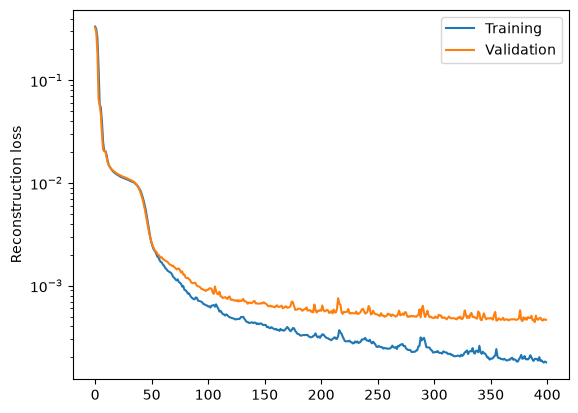

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.set(ylabel='Reconstruction loss', yscale='log')

df = pd.read_csv("ae_metrics.csv")
df.plot(y='train_loss', label='Training', ax=ax)
df.plot(y='validation_loss', label='Validation', ax=ax)

# Reconstruction of the validation dataset

In [2]:
import torch
from torch.utils.data import DataLoader
from model import Autoencoder
from dataset import LogMinMaxScale, EnsembleDataset
from generate import reconstruct_samples, save_reconstructions

checkpoint = torch.load('ae.pt', map_location='cpu')

## Normalization
min_value = checkpoint['MINVAL']
max_value = checkpoint['MAXVAL']
transform = LogMinMaxScale(min_value, max_value)

# Model
model = Autoencoder(checkpoint['LATENT_DIM'], in_shape=checkpoint['IN_SHAPE'])
model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

In [3]:
import xarray as xr

fname = 'data/helens48.ens.nc'

## Loading raw data and normaliation
ds = xr.open_dataset(fname)
da = ds["tephra_grn_load"]

dataset = EnsembleDataset(da, transform)
loader  = DataLoader(dataset, batch_size=12,shuffle=False)

In [4]:
fname = "reconstructions.nc"
reconstructions, targets = reconstruct_samples(model,loader)
save_reconstructions(fname,reconstructions, targets)

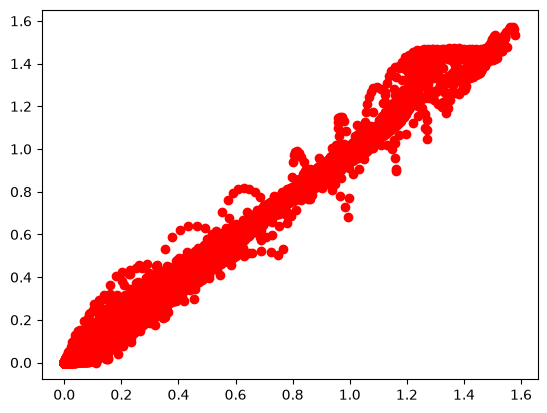

In [11]:
plt.plot(reconstructions[3].flatten(),targets[3].flatten(), 'ro')


# Model summary

In [5]:
from torchsummary import summary
H,W = checkpoint['IN_SHAPE']
summary(model, (1,H,W))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 128, 256]             160
              ReLU-2         [-1, 16, 128, 256]               0
            Conv2d-3          [-1, 32, 64, 128]           4,640
              ReLU-4          [-1, 32, 64, 128]               0
            Conv2d-5           [-1, 64, 32, 64]          18,496
              ReLU-6           [-1, 64, 32, 64]               0
           Flatten-7               [-1, 131072]               0
            Linear-8                   [-1, 64]       8,388,672
            Linear-9               [-1, 131072]       8,519,680
             ReLU-10               [-1, 131072]               0
        Unflatten-11           [-1, 64, 32, 64]               0
         Upsample-12          [-1, 64, 64, 128]               0
           Conv2d-13          [-1, 32, 64, 128]          18,464
             ReLU-14          [-1, 32, 